Epoch 1/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 608ms/step - accuracy: 0.3507 - loss: 3.7697 - val_accuracy: 0.6333 - val_loss: 2.0780 - learning_rate: 0.0010
Epoch 2/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6602 - loss: 1.8080 - val_accuracy: 0.6167 - val_loss: 1.7340 - learning_rate: 0.0010
Epoch 3/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6612 - loss: 1.6062 - val_accuracy: 0.6333 - val_loss: 1.7546 - learning_rate: 0.0010
Epoch 4/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6625 - loss: 1.6348 - val_accuracy: 0.6333 - val_loss: 1.5772 - learning_rate: 0.0010
Epoch 5/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6803 - loss: 1.4895 - val_accuracy: 0.6333 - val_loss: 1.6064 - learning_rate: 0.0010
Epoch 6/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7024 - loss: 1.4038 - val_accuracy: 0.6333 - val_loss: 1.5595 - learning_rate: 0.0010
Epoch 7/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6676 - loss: 1.3507 - val_accuracy:

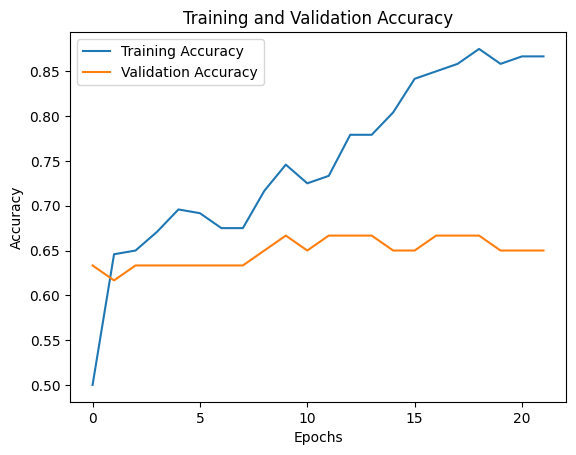

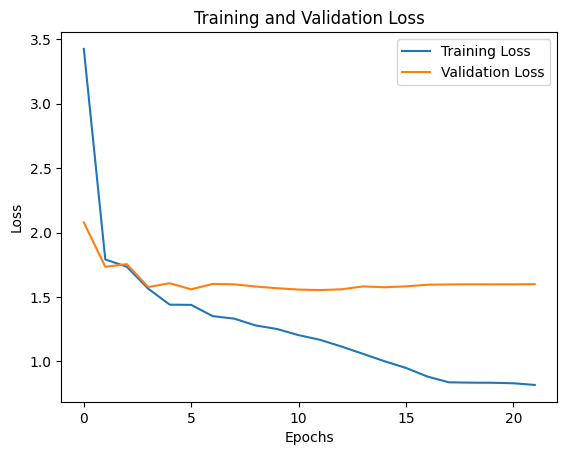

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 899ms/step
English: What is your name?
Translated Hindi: आप क्या है है

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
English: I love Kota
Translated Hindi: मैं आपसे

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
English: My name is Atul
Translated Hindi: है



In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Expanded dataset (English to Hindi)
data = [
    ("Hello", "नमस्ते"),
    ("How are you?", "आप कैसे हैं?"),
    ("I am fine", "मैं ठीक हूँ"),
    ("What is your name?", "आपका नाम क्या है?"),
    ("Thank you", "धन्यवाद"),
    ("Good morning", "शुभ प्रभात"),
    ("Good night", "शुभ रात्रि"),
    ("I love you", "मैं आपसे प्यार करता हूँ"),
    ("See you later", "बाद में मिलते हैं"),
    ("Have a nice day", "आपका दिन शुभ हो"),
    ("Where are you going?", "आप कहाँ जा रहे हैं?"),
    ("I am going to the market", "मैं बाजार जा रहा हूँ"),
    ("What are you doing?", "आप क्या कर रहे हैं?"),
    ("I am reading a book", "मैं एक किताब पढ़ रहा हूँ"),
    ("This is a pen", "यह एक कलम है"),
    ("That is a book", "वह एक किताब है"),
    ("How old are you?", "आपकी उम्र क्या है?"),
    ("I am 25 years old", "मैं 25 साल का हूँ"),
    ("Where do you live?", "आप कहाँ रहते हैं?"),
    ("I live in Delhi", "मैं दिल्ली में रहता हूँ"),
    ("Where is the station?", "स्टेशन कहाँ है?"),
    ("I need help", "मुझे मदद चाहिए"),
    ("What time is it?", "क्या समय हुआ है?"),
    ("I am hungry", "मुझे भूख लगी है"),
    ("Let's go", "चलो चलते हैं"),
    ("This is amazing", "यह अद्भुत है"),
    ("I don't understand", "मैं समझा नहीं"),
    ("Please repeat", "कृपया दोहराएँ"),
    ("How much does it cost?", "इसकी कीमत क्या है?"),
    ("I am sorry", "मुझे माफ करें"),
]

# Split into English and Hindi sentences
english_sentences = [pair[0] for pair in data]
hindi_sentences = [pair[1] for pair in data]

# Tokenization
english_tokenizer = Tokenizer()
english_tokenizer.fit_on_texts(english_sentences)
english_sequences = english_tokenizer.texts_to_sequences(english_sentences)
english_vocab_size = len(english_tokenizer.word_index) + 1

hindi_tokenizer = Tokenizer()
hindi_tokenizer.fit_on_texts(hindi_sentences)
hindi_sequences = hindi_tokenizer.texts_to_sequences(hindi_sentences)
hindi_vocab_size = len(hindi_tokenizer.word_index) + 1

# Pad sequences
max_sequence_length = 10  # Fixed length for simplicity
english_padded = pad_sequences(english_sequences, maxlen=max_sequence_length, padding='post')
hindi_padded = pad_sequences(hindi_sequences, maxlen=max_sequence_length, padding='post')

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(english_padded, hindi_padded, test_size=0.2, random_state=42)

# Build the RNN model
embedding_dim = 128
rnn_units = 256

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=english_vocab_size, output_dim=embedding_dim, input_length=max_sequence_length),
    tf.keras.layers.SimpleRNN(rnn_units, return_sequences=True, dropout=0.2),
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(hindi_vocab_size, activation='softmax'))
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Prepare target data for training
y_train = np.expand_dims(y_train, -1)
y_test = np.expand_dims(y_test, -1)

# Callbacks
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, epochs=150, validation_data=(X_test, y_test), batch_size=4, callbacks=[lr_scheduler, early_stopping])

# Evaluate the model
loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Sample translation function
def translate_sentence(sentence):
    sequence = english_tokenizer.texts_to_sequences([sentence])
    padded_sequence = pad_sequences(sequence, maxlen=max_sequence_length, padding='post')
    predicted_sequence = model.predict(padded_sequence)
    predicted_indices = np.argmax(predicted_sequence, axis=-1)
    translated_sentence = hindi_tokenizer.sequences_to_texts(predicted_indices)
    return translated_sentence[0]

# Test translations
sample_sentences = [
    "What is your name?",
    "I love Kota",
    "My name is Atul"
]

for sentence in sample_sentences:
    translated_hindi = translate_sentence(sentence)
    print(f"English: {sentence}")
    print(f"Translated Hindi: {translated_hindi}")
    print()